# Congressional Trade ML Modeling

In [4]:
# Load and Prepare Data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/trades_with_returns.csv')

# Remove rows without target
df_clean = df.dropna(subset=['outperformed_90d'])
print(f"Dataset: {len(df_clean)} trades with valid targets")

Dataset: 8689 trades with valid targets


# Prepare data for modeling


In [5]:
#Feature Selection
feature_cols = [
    'age', 'num_committees', 'committee_power_score', 'is_committee_leader',
    'filed_after_days', 'trade_amount', 'is_buy', 'is_sell',
    'trade_year', 'trade_month', 'is_joint_ownership'
]

# One-hot encode party
df_clean = pd.get_dummies(df_clean, columns=['party'], drop_first=True)
if 'party_Republican' in df_clean.columns:
    feature_cols.append('party_Republican')

X = df_clean[feature_cols].fillna(0)
y = df_clean['outperformed_90d']

print(f"Features: {len(feature_cols)}")
print(f"Class balance: {y.value_counts()}")

#Train/Test Split (TEMPORAL)
df_clean = df_clean.sort_values('traded_date')
split_idx = int(len(df_clean) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\nTraining set: {len(X_train)}")
print(f"Test set: {len(X_test)}")


Features: 12
Class balance: outperformed_90d
0.0    5755
1.0    2934
Name: count, dtype: int64

Training set: 6951
Test set: 1738


# Logistic Regression

In [6]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


LOGISTIC REGRESSION RESULTS
Accuracy: 0.667
ROC-AUC: 0.488

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.99      0.80      1154
         1.0       0.65      0.02      0.04       584

    accuracy                           0.67      1738
   macro avg       0.66      0.51      0.42      1738
weighted avg       0.66      0.67      0.54      1738



# Random Forest


In [7]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



RANDOM FOREST RESULTS
Accuracy: 0.663
ROC-AUC: 0.606

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.98      0.79      1154
         1.0       0.47      0.03      0.06       584

    accuracy                           0.66      1738
   macro avg       0.57      0.51      0.43      1738
weighted avg       0.60      0.66      0.55      1738



## Model Comparison & Summarization



Top 10 Most Important Features:
                  feature  importance
9             trade_month    0.400645
4        filed_after_days    0.202178
0                     age    0.098168
2   committee_power_score    0.079743
1          num_committees    0.062286
5            trade_amount    0.055761
8              trade_year    0.026769
11       party_Republican    0.021071
3     is_committee_leader    0.017802
7                 is_sell    0.015082


<Figure size 1000x600 with 0 Axes>

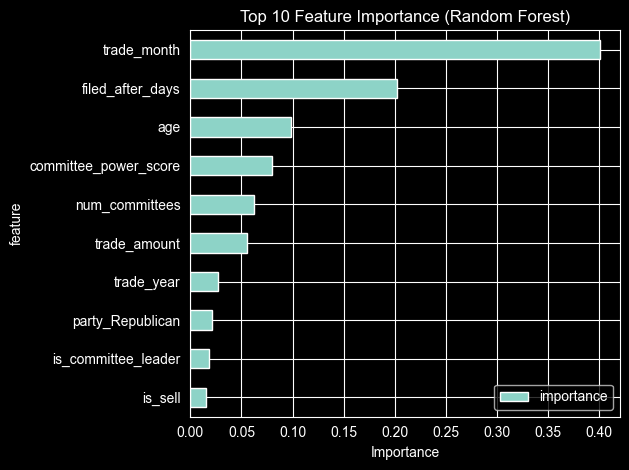


MODEL COMPARISON
                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.667434  0.487774
1        Random Forest  0.662831  0.606372


In [9]:

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(x='feature', y='importance', kind='barh')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results)